<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/deep07sec2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [ ]:
!pip uninstall tensorflow

Found existing installation: tensorflow 2.12.0
Uninstalling tensorflow-2.12.0:
  Would remove:
    /usr/local/bin/estimator_ckpt_converter
    /usr/local/bin/import_pb_to_tensorboard
    /usr/local/bin/saved_model_cli
    /usr/local/bin/tensorboard
    /usr/local/bin/tf_upgrade_v2
    /usr/local/bin/tflite_convert
    /usr/local/bin/toco
    /usr/local/bin/toco_from_protos
    /usr/local/lib/python3.11/dist-packages/tensorflow-2.12.0.dist-info/*
    /usr/local/lib/python3.11/dist-packages/tensorflow/*
Proceed (Y/n)? Y
  Successfully uninstalled tensorflow-2.12.0


In [ ]:
!pip install tensorflow==2.12.0

  Using cached tensorflow-2.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
Using cached tensorflow-2.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (586.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.12.0 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.12.0 which is incompatible.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
fmnist_data = keras.datasets.fashion_mnist

In [ ]:
(x_train, y_train), (x_test, y_test) = fmnist_data.load_data()

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
y_train.shape

(60000,)

In [ ]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

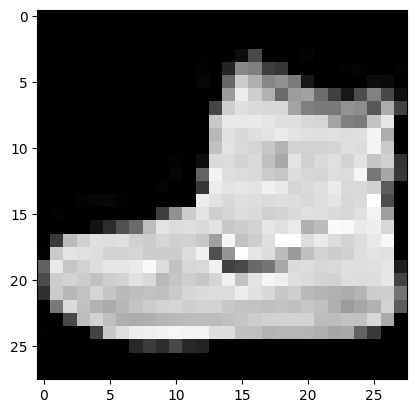

In [ ]:
plt.imshow(x_train[0,], cmap="gray")

In [ ]:
x_train, x_test = x_train/255.0, x_test/255.0

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
init_1 = keras.initializers.VarianceScaling(scale=2.0, mode='fan_avg')
#fan_in fan_out
#init_1  = GlorotUniform() or initializer = GlorotNormal()
#init_1  = HeNormal()  or initializer = HeUniform()
#init_1 =keras.initializers.LecunNormal()
#init_1 =keras.initializers.LecunUniform()
#keras.initializers.VarianceScaling(scale=1.0, mode="fan_in", distribution="truncated_normal")


In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, kernel_initializer=init_1, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("elu"),#selu  relu
    keras.layers.Dense(75, use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(alpha=0.3),
    keras.layers.Dense(10, activation="softmax")
])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 batch_normalization (BatchN  (None, 784)              3136      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 100)               78400     
                                                                 
 batch_normalization_1 (Batc  (None, 100)              400       
 hNormalization)                                                 
                                                                 
 activation (Activation)     (None, 100)               0         
                                                                 
 dense_1 (Dense)             (None, 75)                7

In [ ]:
#Power lr
sgd = tf.keras.optimizers.legacy.SGD(decay=1e-3)
#sgd = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True, weight_decay=1e-3)

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=sgd,
              metrics=["accuracy"])

In [ ]:
history_power = model.fit(x_train, y_train, epochs=10, validation_split=0.15)

Epoch 1/10
1594/1594 [==============================] - 12s 6ms/step - loss: 0.5065 - accuracy: 0.8208 - val_loss: 0.4014 - val_accuracy: 0.8539
Epoch 2/10
1594/1594 [==============================] - 17s 10ms/step - loss: 0.3972 - accuracy: 0.8559 - val_loss: 0.3793 - val_accuracy: 0.8630
Epoch 3/10
1594/1594 [==============================] - 10s 6ms/step - loss: 0.3679 - accuracy: 0.8658 - val_loss: 0.3458 - val_accuracy: 0.8743
Epoch 4/10
1594/1594 [==============================] - 10s 6ms/step - loss: 0.3433 - accuracy: 0.8745 - val_loss: 0.3364 - val_accuracy: 0.8766
Epoch 5/10
1594/1594 [==============================] - 9s 5ms/step - loss: 0.3257 - accuracy: 0.8800 - val_loss: 0.3453 - val_accuracy: 0.8741
Epoch 6/10
1594/1594 [==============================] - 10s 6ms/step - loss: 0.3145 - accuracy: 0.8845 - val_loss: 0.3365 - val_accuracy: 0.8737
Epoch 7/10
1594/1594 [==============================] - 10s 6ms/step - loss: 0.3040 - accuracy: 0.8876 - val_loss: 0.3302 - val_ac

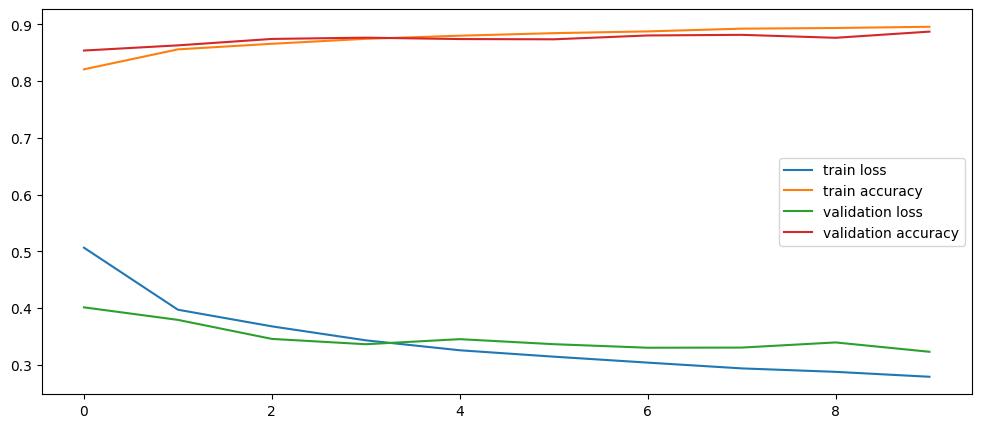

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history_power.history["loss"], label="train loss")
ax.plot(history_power.history["accuracy"], label="train accuracy")
ax.plot(history_power.history["val_loss"], label="validation loss")
ax.plot(history_power.history["val_accuracy"], label="validation accuracy")
ax.legend()